In [41]:
# =============================================================================
# GPAY EXPENSE TRACKER
# STEP 1 : READ GPAY STATEMENT
# =============================================================================

import os
import re
import pdfplumber
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# PROJECT DIRECTORY
# =============================================================================

PROJECT_DIR = r"C:\Saikat\ME\ME_March2June"

SOURCE_DIR = os.path.join(PROJECT_DIR, "Source")
DATA_DIR = os.path.join(PROJECT_DIR, "Data")
FIGURE_DIR = os.path.join(PROJECT_DIR, "Figures")
REPORT_DIR = os.path.join(PROJECT_DIR, "Reports")

for folder in [SOURCE_DIR, DATA_DIR, FIGURE_DIR, REPORT_DIR]:
    os.makedirs(folder, exist_ok=True)

print("="*70)
print("PROJECT FOLDERS CREATED")
print("="*70)

print("Project :", PROJECT_DIR)
print("Source  :", SOURCE_DIR)
print("Data    :", DATA_DIR)
print("Figures :", FIGURE_DIR)
print("Reports :", REPORT_DIR)

# =============================================================================
# PDF FILE
# =============================================================================

pdf_path = r"C:\Saikat\ME\gpay_statement_20260301_20260531.pdf"

# =============================================================================
# READ PDF
# =============================================================================

print("\nReading PDF...")

text = ""

with pdfplumber.open(pdf_path) as pdf:

    print(f"Total Pages : {len(pdf.pages)}")

    for page in pdf.pages:

        page_text = page.extract_text()

        if page_text:
            text += page_text + "\n"

print("PDF Successfully Read.")

# =============================================================================
# STORE LINES
# =============================================================================

lines = [
    line.strip()
    for line in text.split("\n")
    if line.strip()
]

print(f"\nTotal Lines : {len(lines)}")

# =============================================================================
# PREVIEW
# =============================================================================

print("\nFIRST 30 LINES")
print("="*70)

for i, line in enumerate(lines[:30]):
    print(f"{i:03d} : {line}")

# =============================================================================
# SAVE RAW TEXT
# =============================================================================

raw_text_path = os.path.join(DATA_DIR, "Raw_GPay_Statement.txt")

with open(raw_text_path, "w", encoding="utf-8") as f:
    f.write(text)

print("\nRaw text saved to:")
print(raw_text_path)

PROJECT FOLDERS CREATED
Project : C:\Saikat\ME\ME_March2June
Source  : C:\Saikat\ME\ME_March2June\Source
Data    : C:\Saikat\ME\ME_March2June\Data
Figures : C:\Saikat\ME\ME_March2June\Figures
Reports : C:\Saikat\ME\ME_March2June\Reports

Reading PDF...
Total Pages : 72
PDF Successfully Read.

Total Lines : 2576

FIRST 30 LINES
000 : Transaction statement
001 : 9800146199, sm639948@gmail.com
002 : Transactionstatementperiod Sent Received
003 : 01March2026-31May2026 ₹2,76,514.24 ₹16,043
004 : Date&time Transactiondetails Amount
005 : 01Mar,2026 PaidtoZEPTOMARKETPLACEPRIVATELIMITED ₹108
006 : 12:34AM UPITransactionID:642634470418
007 : PaidbyAirtelPaymentsBank6199
008 : 01Mar,2026 PaidtoMEESHOTECHNOLOGIESPRIVATELIMITED ₹97
009 : 01:54AM UPITransactionID:642686378476
010 : PaidbyAirtelPaymentsBank6199
011 : 01Mar,2026 PaidtoMyntra ₹506
012 : 03:57AM UPITransactionID:642697968618
013 : PaidbyAirtelPaymentsBank6199
014 : 01Mar,2026 PaidtoSONUKUMARPRASAD ₹117
015 : 04:46AM UPITransactionID:64

In [42]:
# =============================================================================
# STEP 2 : EXTRACT TRANSACTIONS
# =============================================================================

print("\nExtracting transactions...")

# -------------------------------------------------------------------------
# Regular Expressions
# -------------------------------------------------------------------------

transaction_pattern = re.compile(
    r"(\d{2}[A-Za-z]{3},\d{4})\s+(.*?)\s+₹([\d,]+(?:\.\d+)?)"
)

time_pattern = re.compile(r"(\d{2}:\d{2}[AP]M)")

upi_pattern = re.compile(r"UPITransactionID:\s*(\d+)")

transactions = []

i = 0

while i < len(lines):

    line = lines[i]

    match = transaction_pattern.match(line)

    if match:

        date = match.group(1)
        details = match.group(2)
        amount = float(match.group(3).replace(",", ""))

        time = ""
        upi = ""
        bank = ""

        # ----------------------------------------------------------
        # Second Line
        # ----------------------------------------------------------

        if i + 1 < len(lines):

            second = lines[i + 1]

            t = time_pattern.search(second)
            if t:
                time = t.group(1)

            u = upi_pattern.search(second)
            if u:
                upi = u.group(1)

        # ----------------------------------------------------------
        # Third Line
        # ----------------------------------------------------------

        if i + 2 < len(lines):

            third = lines[i + 2]

            if (
                third.startswith("Paidby")
                or third.startswith("Receivedin")
                or third.startswith("Creditedto")
            ):
                bank = third

        transactions.append({
            "Date": date,
            "Time": time,
            "Details": details,
            "Amount": amount,
            "UPI_ID": upi,
            "Bank": bank
        })

        i += 3

    else:
        i += 1

# =============================================================================
# DATAFRAME
# =============================================================================

df = pd.DataFrame(transactions)

print("="*70)
print(f"Transactions Extracted : {len(df)}")
print("="*70)

print(df.head(10))

# =============================================================================
# SAVE RAW TRANSACTIONS
# =============================================================================

raw_transaction_csv = os.path.join(
    DATA_DIR,
    "Transactions_Raw.csv"
)

raw_transaction_excel = os.path.join(
    REPORT_DIR,
    "Transactions_Raw.xlsx"
)

df.to_csv(
    raw_transaction_csv,
    index=False
)

df.to_excel(
    raw_transaction_excel,
    index=False
)

print("\nRaw Transactions Saved.")

print(raw_transaction_csv)
print(raw_transaction_excel)


Extracting transactions...
Transactions Extracted : 714
         Date     Time                                       Details  Amount  \
0  01Mar,2026  12:34AM          PaidtoZEPTOMARKETPLACEPRIVATELIMITED   108.0   
1  01Mar,2026  01:54AM        PaidtoMEESHOTECHNOLOGIESPRIVATELIMITED    97.0   
2  01Mar,2026  03:57AM                                  PaidtoMyntra   506.0   
3  01Mar,2026  04:46AM                         PaidtoSONUKUMARPRASAD   117.0   
4  01Mar,2026  05:29AM                         PaidtoRentomojoPvtLtd   776.0   
5  01Mar,2026  02:55PM                                   PaidtoZepto   106.0   
6  01Mar,2026  03:31PM        PaidtoMeeshoTechnologiesPrivateLimited   354.0   
7  01Mar,2026  04:06PM  ReceivedfromMeeshoTechnologiesPrivateLimited   206.0   
8  01Mar,2026  04:06PM  ReceivedfromGoogleIndiaDigitalServicesPvtLtd   206.0   
9  01Mar,2026  07:57PM         PaidtoSANGAMSWEETSANDSNACKSRESTAURANT    50.0   

         UPI_ID                          Bank  
0  64263447041

In [43]:
# =============================================================================
# STEP 3 : CLEAN DATA
# =============================================================================

print("\nCleaning transaction data...")

# =============================================================================
# DATE
# =============================================================================

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d%b,%Y"
)

# =============================================================================
# TIME
# =============================================================================

df["Time"] = pd.to_datetime(
    df["Time"],
    format="%I:%M%p",
    errors="coerce"
).dt.strftime("%I:%M %p")

# =============================================================================
# TYPE
# =============================================================================

df["Type"] = np.where(
    df["Details"].str.contains(
        "Received",
        case=False,
        na=False
    ),
    "Income",
    "Expense"
)

# =============================================================================
# MERCHANT
# =============================================================================

df["Merchant"] = (
    df["Details"]
      .str.replace("Paidto", "", regex=False)
      .str.replace("Receivedfrom", "", regex=False)
      .str.replace("ReceivedFrom", "", regex=False)
      .str.replace("Received in", "", regex=False)
      .str.strip()
)

# =============================================================================
# DATE INFORMATION
# =============================================================================

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month_name()

df["Month_Number"] = df["Date"].dt.month

df["Day"] = df["Date"].dt.day

df["Weekday"] = df["Date"].dt.day_name()

df["Week_Number"] = df["Date"].dt.isocalendar().week

# =============================================================================
# HOUR
# =============================================================================

df["Hour"] = pd.to_datetime(
    df["Time"],
    format="%I:%M %p",
    errors="coerce"
).dt.hour

# =============================================================================
# SORT
# =============================================================================

df = df.sort_values(
    ["Date", "Time"]
).reset_index(drop=True)

# =============================================================================
# DISPLAY
# =============================================================================

print("=" * 80)
print("DATA AFTER CLEANING")
print("=" * 80)

print(df.head(10))

print("\nColumns")

print(df.columns.tolist())

# =============================================================================
# SAVE CLEAN DATA
# =============================================================================

clean_csv = os.path.join(
    DATA_DIR,
    "Transactions_Clean.csv"
)

clean_excel = os.path.join(
    REPORT_DIR,
    "Transactions_Clean.xlsx"
)

df.to_csv(
    clean_csv,
    index=False
)

df.to_excel(
    clean_excel,
    index=False
)

print("\nClean data saved.")

print(clean_csv)
print(clean_excel)


Cleaning transaction data...
DATA AFTER CLEANING
        Date      Time                                       Details  Amount  \
0 2026-03-01  01:54 AM        PaidtoMEESHOTECHNOLOGIESPRIVATELIMITED    97.0   
1 2026-03-01  02:55 PM                                   PaidtoZepto   106.0   
2 2026-03-01  03:31 PM        PaidtoMeeshoTechnologiesPrivateLimited   354.0   
3 2026-03-01  03:57 AM                                  PaidtoMyntra   506.0   
4 2026-03-01  04:06 PM  ReceivedfromMeeshoTechnologiesPrivateLimited   206.0   
5 2026-03-01  04:06 PM  ReceivedfromGoogleIndiaDigitalServicesPvtLtd   206.0   
6 2026-03-01  04:46 AM                         PaidtoSONUKUMARPRASAD   117.0   
7 2026-03-01  05:29 AM                         PaidtoRentomojoPvtLtd   776.0   
8 2026-03-01  07:57 PM         PaidtoSANGAMSWEETSANDSNACKSRESTAURANT    50.0   
9 2026-03-01  07:58 PM                        PaidtoNISHAJUICECORNER    50.0   

         UPI_ID                          Bank     Type  \
0  64268637

In [44]:
# =============================================================================
# STEP 4 : CATEGORIZE TRANSACTIONS
# =============================================================================

print("\nCategorizing transactions...")

# =============================================================================
# CATEGORY DICTIONARY
# =============================================================================

CATEGORY_MAP = {

    # -------------------------------------------------
    # Groceries
    # -------------------------------------------------
    "ZEPTO": "Groceries",
    "BLINKIT": "Groceries",
    "BIGBASKET": "Groceries",
    "DMART": "Groceries",
    "INSTAMART": "Groceries",

    # -------------------------------------------------
    # Food
    # -------------------------------------------------
    "SWIGGY": "Food",
    "ZOMATO": "Food",
    "DOMINOS": "Food",
    "PIZZA": "Food",
    "KFC": "Food",
    "MCDONALD": "Food",
    "BURGER": "Food",
    "RESTAURANT": "Food",
    "SANGAM": "Food",

    # -------------------------------------------------
    # Shopping
    # -------------------------------------------------
    "AMAZON": "Shopping",
    "FLIPKART": "Shopping",
    "MYNTRA": "Shopping",
    "MEESHO": "Shopping",
    "AJIO": "Shopping",
    "NYKAA": "Shopping",

    # -------------------------------------------------
    # Transport
    # -------------------------------------------------
    "UBER": "Transport",
    "OLA": "Transport",
    "IRCTC": "Transport",
    "RAPIDO": "Transport",

    # -------------------------------------------------
    # Fuel
    # -------------------------------------------------
    "PETROL": "Fuel",
    "INDIANOIL": "Fuel",
    "HPCL": "Fuel",
    "BPCL": "Fuel",

    # -------------------------------------------------
    # Rent
    # -------------------------------------------------
    "RENTOMOJO": "Rent",

    # -------------------------------------------------
    # Recharge
    # -------------------------------------------------
    "AIRTEL": "Recharge",
    "JIO": "Recharge",
    "BSNL": "Recharge",

    # -------------------------------------------------
    # Utilities
    # -------------------------------------------------
    "ELECTRICITY": "Utilities",
    "WATER": "Utilities",
    "GAS": "Utilities",

    # -------------------------------------------------
    # Income
    # -------------------------------------------------
    "GOOGLE INDIA": "Income",
}

# =============================================================================
# CATEGORY FUNCTION
# =============================================================================

def get_category(merchant):

    merchant = str(merchant).upper()

    for keyword, category in CATEGORY_MAP.items():

        if keyword in merchant:
            return category

    return "Others"

# =============================================================================
# APPLY CATEGORY
# =============================================================================

df["Category"] = df["Merchant"].apply(get_category)

# =============================================================================
# DISPLAY
# =============================================================================

print("="*70)
print("CATEGORY COUNTS")
print("="*70)

print(df["Category"].value_counts())

print("\nSample")

print(df[["Merchant", "Category"]].head(25))

# =============================================================================
# SAVE
# =============================================================================

category_csv = os.path.join(
    DATA_DIR,
    "Transactions_Categorized.csv"
)

category_excel = os.path.join(
    REPORT_DIR,
    "Transactions_Categorized.xlsx"
)

df.to_csv(category_csv, index=False)
df.to_excel(category_excel, index=False)

print("\nCategorized data saved.")


Categorizing transactions...
CATEGORY COUNTS
Category
Others       578
Food          58
Groceries     42
Shopping      17
Recharge      11
Rent           5
Transport      3
Name: count, dtype: int64

Sample
                            Merchant   Category
0   MEESHOTECHNOLOGIESPRIVATELIMITED   Shopping
1                              Zepto  Groceries
2   MeeshoTechnologiesPrivateLimited   Shopping
3                             Myntra   Shopping
4   MeeshoTechnologiesPrivateLimited   Shopping
5   GoogleIndiaDigitalServicesPvtLtd     Others
6                    SONUKUMARPRASAD     Others
7                    RentomojoPvtLtd       Rent
8    SANGAMSWEETSANDSNACKSRESTAURANT       Food
9                   NISHAJUICECORNER     Others
10    ZEPTOMARKETPLACEPRIVATELIMITED  Groceries
11                            Zomato       Food
12                     TuvarDharmesh     Others
13                     SwiggyLimited       Food
14                          ZEPTONOW  Groceries
15                      

In [45]:
# =============================================================================
# STEP 5 : ANALYSIS
# =============================================================================

print("\nGenerating analysis...")

# =============================================================================
# SPLIT DATA
# =============================================================================

expense_df = df[df["Type"] == "Expense"].copy()
income_df = df[df["Type"] == "Income"].copy()

# =============================================================================
# OVERALL SUMMARY
# =============================================================================

total_income = income_df["Amount"].sum()
total_expense = expense_df["Amount"].sum()
net_savings = total_income - total_expense

total_transactions = len(df)
expense_transactions = len(expense_df)
income_transactions = len(income_df)

average_transaction = expense_df["Amount"].mean()
median_transaction = expense_df["Amount"].median()

largest_expense = expense_df["Amount"].max()
largest_income = income_df["Amount"].max() if len(income_df) > 0 else 0

# =============================================================================
# CATEGORY SUMMARY
# =============================================================================

category_summary = (
    expense_df
    .groupby("Category", as_index=False)
    .agg(
        Total_Expense=("Amount", "sum"),
        Transactions=("Amount", "count"),
        Average_Expense=("Amount", "mean")
    )
    .sort_values("Total_Expense", ascending=False)
)

# =============================================================================
# MERCHANT SUMMARY
# =============================================================================

merchant_summary = (
    expense_df
    .groupby("Merchant", as_index=False)
    .agg(
        Total_Expense=("Amount", "sum"),
        Transactions=("Amount", "count")
    )
    .sort_values("Total_Expense", ascending=False)
)

# =============================================================================
# MONTHLY SUMMARY
# =============================================================================

monthly_summary = (
    df.groupby(["Month", "Type"])["Amount"]
      .sum()
      .unstack(fill_value=0)
      .reset_index()
)

if "Income" not in monthly_summary.columns:
    monthly_summary["Income"] = 0

if "Expense" not in monthly_summary.columns:
    monthly_summary["Expense"] = 0

monthly_summary["Savings"] = (
    monthly_summary["Income"]
    - monthly_summary["Expense"]
)

# =============================================================================
# DAILY SUMMARY
# =============================================================================

daily_summary = (
    expense_df
    .groupby("Date", as_index=False)
    .agg(
        Daily_Expense=("Amount", "sum"),
        Transactions=("Amount", "count")
    )
)

# =============================================================================
# WEEKDAY SUMMARY
# =============================================================================

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_summary = (
    expense_df
    .groupby("Weekday", as_index=False)["Amount"]
    .sum()
)

weekday_summary["Weekday"] = pd.Categorical(
    weekday_summary["Weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_summary = weekday_summary.sort_values("Weekday")

# =============================================================================
# HOURLY SUMMARY
# =============================================================================

hourly_summary = (
    expense_df
    .groupby("Hour", as_index=False)["Amount"]
    .sum()
)

# =============================================================================
# LARGEST EXPENSES
# =============================================================================

largest_expenses = (
    expense_df
    .sort_values("Amount", ascending=False)
    .head(20)
)

# =============================================================================
# TOP MERCHANTS
# =============================================================================

top10_merchants = merchant_summary.head(10)

# =============================================================================
# PRINT SUMMARY
# =============================================================================

print("="*70)
print("SUMMARY")
print("="*70)

print(f"Total Income           : ₹{total_income:,.2f}")
print(f"Total Expense          : ₹{total_expense:,.2f}")
print(f"Net Savings            : ₹{net_savings:,.2f}")

print()

print(f"Transactions           : {total_transactions}")
print(f"Expense Transactions   : {expense_transactions}")
print(f"Income Transactions    : {income_transactions}")

print()

print(f"Average Expense        : ₹{average_transaction:,.2f}")
print(f"Median Expense         : ₹{median_transaction:,.2f}")
print(f"Largest Expense        : ₹{largest_expense:,.2f}")
print(f"Largest Income         : ₹{largest_income:,.2f}")

# =============================================================================
# SAVE ALL ANALYSIS TABLES
# =============================================================================

analysis_path = os.path.join(
    REPORT_DIR,
    "Expense_Analysis.xlsx"
)

with pd.ExcelWriter(analysis_path) as writer:

    df.to_excel(writer,
                sheet_name="Transactions",
                index=False)

    category_summary.to_excel(writer,
                              sheet_name="Category Summary",
                              index=False)

    merchant_summary.to_excel(writer,
                              sheet_name="Merchant Summary",
                              index=False)

    monthly_summary.to_excel(writer,
                             sheet_name="Monthly Summary",
                             index=False)

    daily_summary.to_excel(writer,
                           sheet_name="Daily Summary",
                           index=False)

    weekday_summary.to_excel(writer,
                             sheet_name="Weekday Summary",
                             index=False)

    hourly_summary.to_excel(writer,
                            sheet_name="Hourly Summary",
                            index=False)

    largest_expenses.to_excel(writer,
                              sheet_name="Largest Expenses",
                              index=False)

print("\nAnalysis workbook saved.")

print(analysis_path)


Generating analysis...
SUMMARY
Total Income           : ₹16,043.00
Total Expense          : ₹280,514.24
Net Savings            : ₹-264,471.24

Transactions           : 714
Expense Transactions   : 697
Income Transactions    : 17

Average Expense        : ₹402.46
Median Expense         : ₹50.00
Largest Expense        : ₹51,500.00
Largest Income         : ₹10,000.00

Analysis workbook saved.
C:\Saikat\ME\ME_March2June\Reports\Expense_Analysis.xlsx


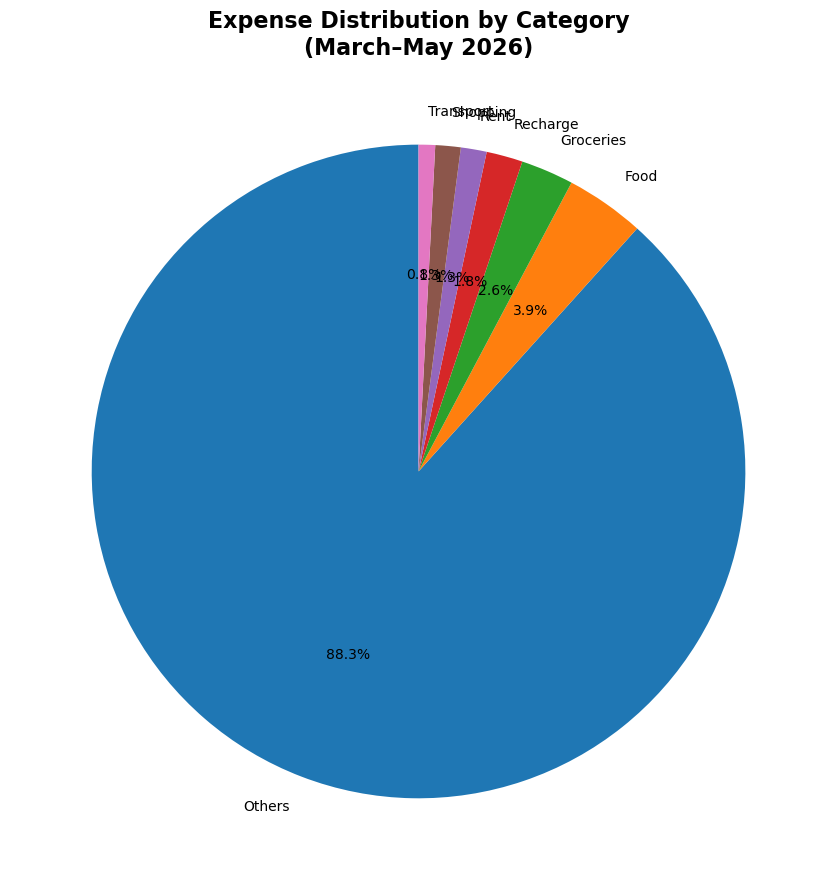

In [46]:
# =============================================================================
# STEP 6.1 : CATEGORY PIE CHART
# =============================================================================

plt.figure(figsize=(9,9))

plt.pie(
    category_summary["Total_Expense"],
    labels=category_summary["Category"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Expense Distribution by Category\n(March–May 2026)",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "01_Category_Pie_Chart_March_to_May_2026.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

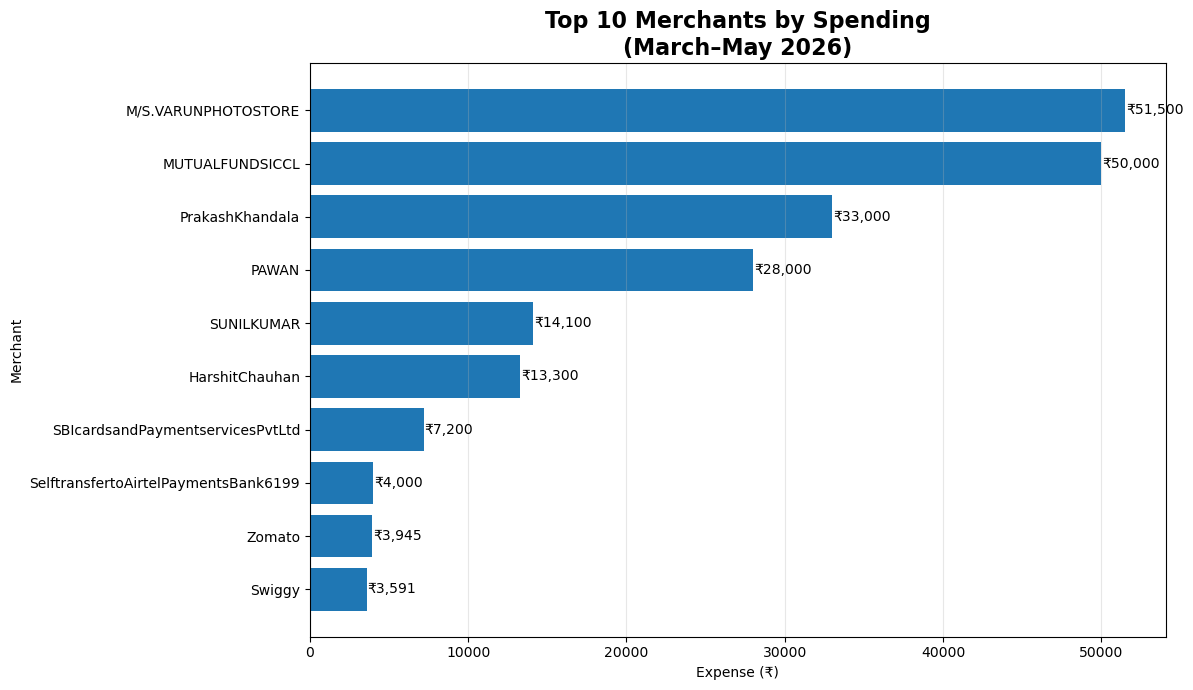

In [47]:
# =============================================================================
# STEP 6.2 : TOP 10 MERCHANTS
# =============================================================================

plt.figure(figsize=(12,7))

bars = plt.barh(
    top10_merchants["Merchant"],
    top10_merchants["Total_Expense"]
)

plt.gca().invert_yaxis()

# Value Labels
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 50,
        bar.get_y() + bar.get_height()/2,
        f"₹{width:,.0f}",
        va="center",
        fontsize=10
    )

plt.xlabel("Expense (₹)")
plt.ylabel("Merchant")

plt.title(
    "Top 10 Merchants by Spending\n(March–May 2026)",
    fontsize=16,
    weight="bold"
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "02_Top_10_Merchants_March_to_May_2026.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

In [48]:
print(df.columns.tolist())

# Create Type column
df["Type"] = df["Details"].str.contains(
    "Receivedfrom|ReceivedFrom",
    case=False,
    na=False
).map({True: "Income", False: "Expense"})

# Create Merchant column
df["Merchant"] = (
    df["Details"]
      .str.replace("Paidto", "", regex=False)
      .str.replace("Receivedfrom", "", regex=False)
      .str.replace("ReceivedFrom", "", regex=False)
      .str.strip()
)

df["Type"] = df["Merchant"].str.contains(
    "Received",
    case=False,
    na=False
).map({True: "Income", False: "Expense"})

print(df.columns)
print(df.head())

['Date', 'Time', 'Details', 'Amount', 'UPI_ID', 'Bank', 'Type', 'Merchant', 'Year', 'Month', 'Month_Number', 'Day', 'Weekday', 'Week_Number', 'Hour', 'Category']
Index(['Date', 'Time', 'Details', 'Amount', 'UPI_ID', 'Bank', 'Type',
       'Merchant', 'Year', 'Month', 'Month_Number', 'Day', 'Weekday',
       'Week_Number', 'Hour', 'Category'],
      dtype='object')
        Date      Time                                       Details  Amount  \
0 2026-03-01  01:54 AM        PaidtoMEESHOTECHNOLOGIESPRIVATELIMITED    97.0   
1 2026-03-01  02:55 PM                                   PaidtoZepto   106.0   
2 2026-03-01  03:31 PM        PaidtoMeeshoTechnologiesPrivateLimited   354.0   
3 2026-03-01  03:57 AM                                  PaidtoMyntra   506.0   
4 2026-03-01  04:06 PM  ReceivedfromMeeshoTechnologiesPrivateLimited   206.0   

         UPI_ID                          Bank     Type  \
0  642686378476  PaidbyAirtelPaymentsBank6199  Expense   
1  606078308631  PaidbyAirtelPayment

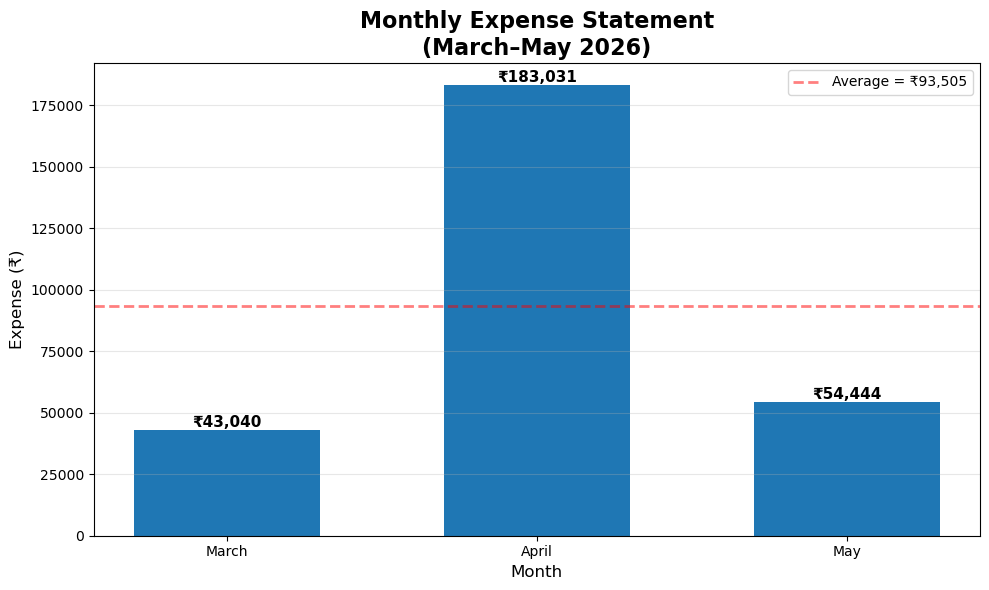

In [49]:
# =============================================================================
# STEP 6.4 : MONTHLY EXPENSES
# =============================================================================

# -------------------------------------------------------------------------
# Monthly Expenses
# -------------------------------------------------------------------------

monthly_expense = (
    expense_df
    .groupby("Month", sort=False)["Amount"]
    .sum()
    .reset_index()
)

# Preserve calendar order
month_order = ["March", "April", "May"]

monthly_expense["Month"] = pd.Categorical(
    monthly_expense["Month"],
    categories=month_order,
    ordered=True
)

monthly_expense = monthly_expense.sort_values("Month")

# Average Monthly Expense
average_monthly = monthly_expense["Amount"].mean()

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

plt.figure(figsize=(10,6))

bars = plt.bar(
    monthly_expense["Month"],
    monthly_expense["Amount"],
    width=0.6
)

# Value labels
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        weight="bold"
    )

# Average line
plt.axhline(
    average_monthly,
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.5,
    label=f"Average = ₹{average_monthly:,.0f}"
)

plt.title(
    "Monthly Expense Statement\n(March–May 2026)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Expense (₹)", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

# -------------------------------------------------------------------------
# Save Figure
# -------------------------------------------------------------------------

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "04_Monthly_Expenses_March_to_May_2026.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

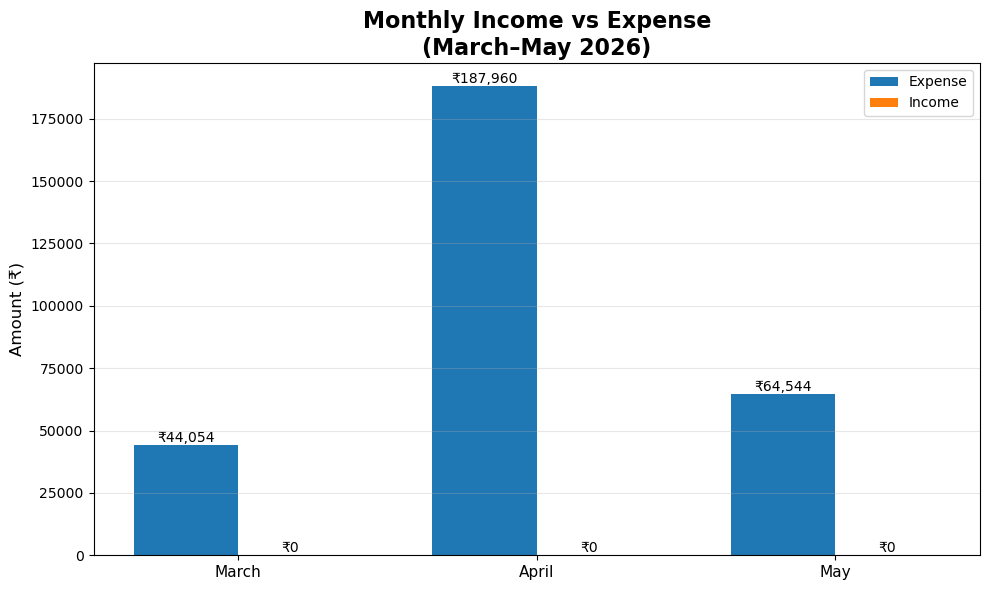

In [51]:
# =============================================================================
# STEP 6.5 : MONTHLY INCOME VS EXPENSE
# =============================================================================

# -------------------------------------------------------------------------
# Prepare Data
# -------------------------------------------------------------------------

monthly_income_expense = (
    df.groupby(["Month", "Type"])["Amount"]
      .sum()
      .unstack(fill_value=0)
)

# -------------------------------------------------------------------------
# Ensure both columns exist
# -------------------------------------------------------------------------

if "Expense" not in monthly_income_expense.columns:
    monthly_income_expense["Expense"] = 0

if "Income" not in monthly_income_expense.columns:
    monthly_income_expense["Income"] = 0

monthly_income_expense = monthly_income_expense.reset_index()

# -------------------------------------------------------------------------
# Keep month order
# -------------------------------------------------------------------------

month_order = ["March", "April", "May"]

monthly_income_expense["Month"] = pd.Categorical(
    monthly_income_expense["Month"],
    categories=month_order,
    ordered=True
)

monthly_income_expense = (
    monthly_income_expense
    .sort_values("Month")
    .reset_index(drop=True)
)

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

x = np.arange(len(monthly_income_expense))
width = 0.35

plt.figure(figsize=(10,6))

bars_expense = plt.bar(
    x - width/2,
    monthly_income_expense["Expense"],
    width,
    label="Expense"
)

bars_income = plt.bar(
    x + width/2,
    monthly_income_expense["Income"],
    width,
    label="Income"
)

# -------------------------------------------------------------------------
# Value Labels
# -------------------------------------------------------------------------

for bars in [bars_expense, bars_income]:

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"₹{height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

# -------------------------------------------------------------------------
# Formatting
# -------------------------------------------------------------------------

plt.xticks(
    x,
    monthly_income_expense["Month"],
    fontsize=11
)

plt.ylabel("Amount (₹)", fontsize=12)

plt.title(
    "Monthly Income vs Expense\n(March–May 2026)",
    fontsize=16,
    weight="bold"
)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

# -------------------------------------------------------------------------
# Save Figure
# -------------------------------------------------------------------------

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "05_Income_vs_Expense_March_to_May_2026.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

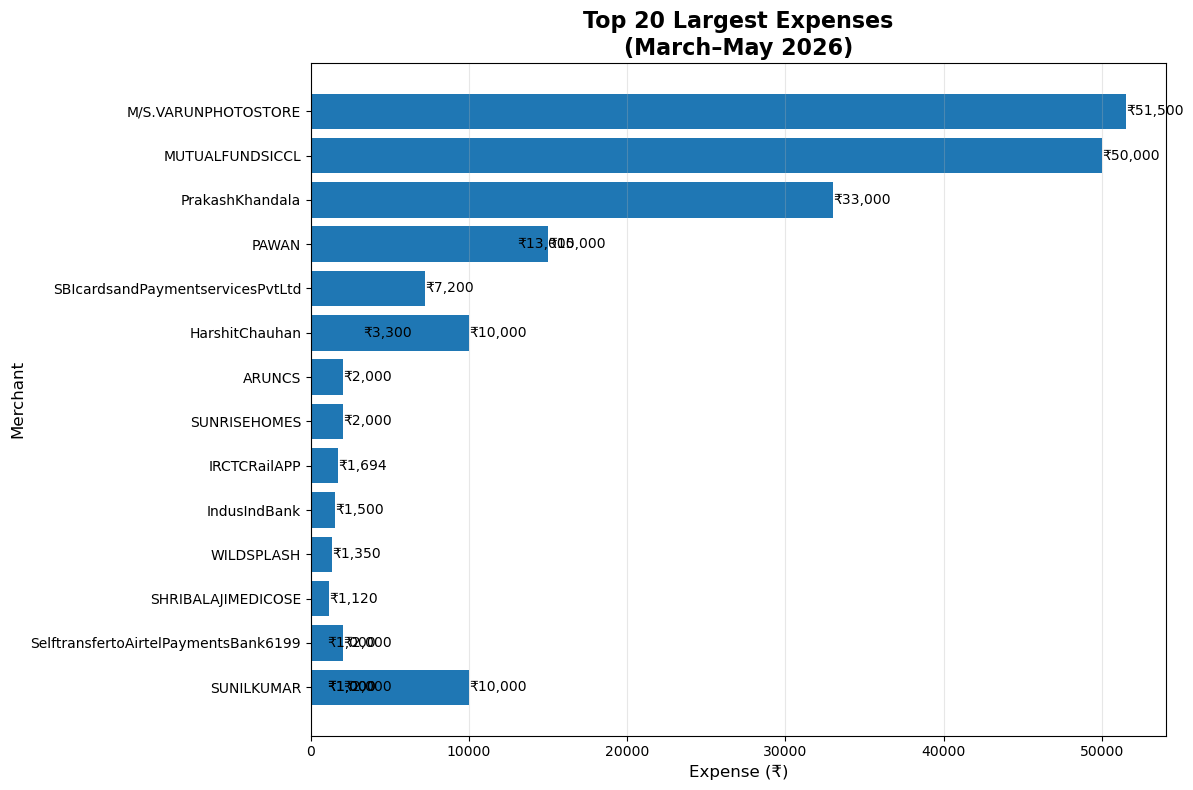

In [52]:
# =============================================================================
# STEP 6.6 : LARGEST EXPENSES
# =============================================================================

# -------------------------------------------------------------------------
# Top 20 Largest Expenses
# -------------------------------------------------------------------------

top20 = (
    expense_df
    .sort_values("Amount", ascending=False)
    .head(20)
)

# Reverse for better horizontal plotting
top20 = top20.iloc[::-1]

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

plt.figure(figsize=(12,8))

bars = plt.barh(
    top20["Merchant"],
    top20["Amount"]
)

# -------------------------------------------------------------------------
# Value Labels
# -------------------------------------------------------------------------

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 20,
        bar.get_y() + bar.get_height()/2,
        f"₹{width:,.0f}",
        va="center",
        fontsize=10
    )

# -------------------------------------------------------------------------
# Formatting
# -------------------------------------------------------------------------

plt.xlabel("Expense (₹)", fontsize=12)
plt.ylabel("Merchant", fontsize=12)

plt.title(
    "Top 20 Largest Expenses\n(March–May 2026)",
    fontsize=16,
    weight="bold"
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

# -------------------------------------------------------------------------
# Save Figure
# -------------------------------------------------------------------------

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "06_Top_20_Largest_Expenses_March_to_May_2026.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

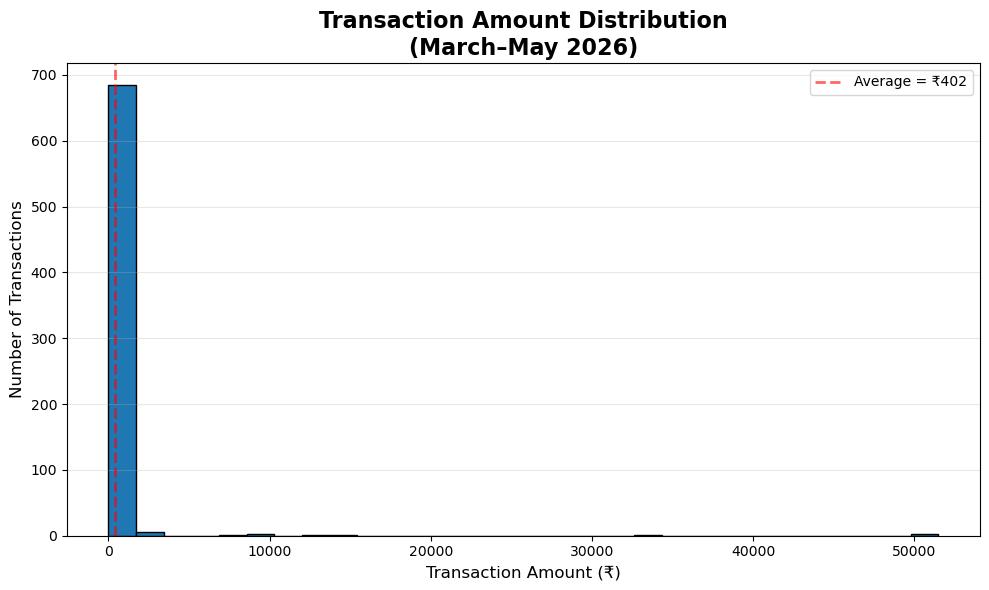

In [53]:
# =============================================================================
# STEP 6.7 : TRANSACTION AMOUNT DISTRIBUTION
# =============================================================================

plt.figure(figsize=(10,6))

plt.hist(
    expense_df["Amount"],
    bins=30,
    edgecolor="black"
)

# Average transaction
avg_transaction = expense_df["Amount"].mean()

plt.axvline(
    avg_transaction,
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.6,
    label=f"Average = ₹{avg_transaction:,.0f}"
)

plt.xlabel("Transaction Amount (₹)", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)

plt.title(
    "Transaction Amount Distribution\n(March–May 2026)",
    fontsize=16,
    weight="bold"
)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

# -------------------------------------------------------------------------
# Save Figure
# -------------------------------------------------------------------------

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "07_Transaction_Amount_Distribution_March_to_May_2026.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

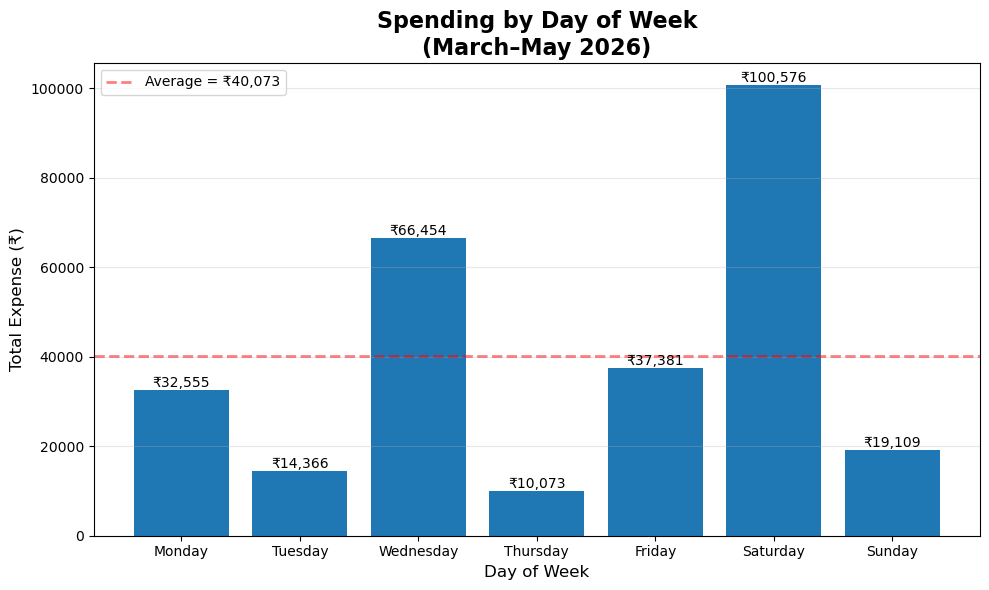

In [54]:
# =============================================================================
# STEP 6.8 : WEEKDAY SPENDING
# =============================================================================

# -------------------------------------------------------------------------
# Weekday Order
# -------------------------------------------------------------------------

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_plot = (
    expense_df
    .groupby("Weekday")["Amount"]
    .sum()
    .reindex(weekday_order)
)

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

plt.figure(figsize=(10,6))

bars = plt.bar(
    weekday_plot.index,
    weekday_plot.values
)

# -------------------------------------------------------------------------
# Value Labels
# -------------------------------------------------------------------------

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# -------------------------------------------------------------------------
# Average Line
# -------------------------------------------------------------------------

average_weekday = weekday_plot.mean()

plt.axhline(
    average_weekday,
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.5,
    label=f"Average = ₹{average_weekday:,.0f}"
)

# -------------------------------------------------------------------------
# Formatting
# -------------------------------------------------------------------------

plt.title(
    "Spending by Day of Week\n(March–May 2026)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Total Expense (₹)", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

# -------------------------------------------------------------------------
# Save Figure
# -------------------------------------------------------------------------

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "08_Weekday_Spending_March_to_May_2026.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

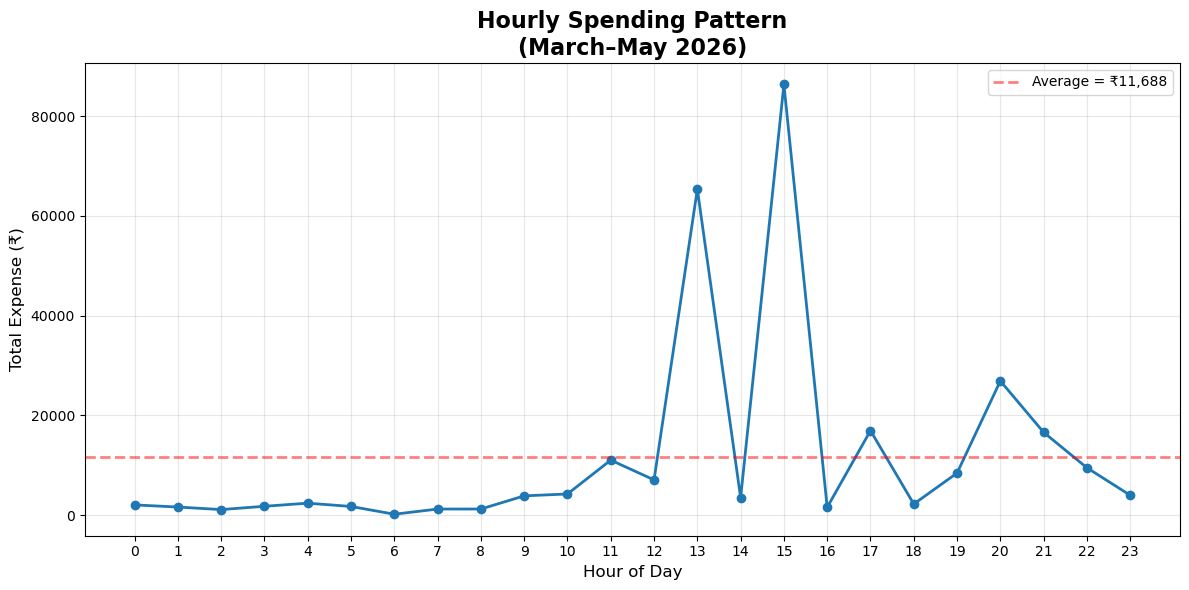

In [55]:
# =============================================================================
# STEP 6.9 : HOURLY SPENDING
# =============================================================================

# -------------------------------------------------------------------------
# Hourly Spending
# -------------------------------------------------------------------------

hourly_plot = (
    expense_df
    .groupby("Hour")["Amount"]
    .sum()
    .reindex(range(24), fill_value=0)
)

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(
    hourly_plot.index,
    hourly_plot.values,
    marker="o",
    linewidth=2,
    markersize=6
)

# -------------------------------------------------------------------------
# Average Line
# -------------------------------------------------------------------------

average_hourly = hourly_plot.mean()

plt.axhline(
    average_hourly,
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.5,
    label=f"Average = ₹{average_hourly:,.0f}"
)

# -------------------------------------------------------------------------
# Formatting
# -------------------------------------------------------------------------

plt.xticks(range(24))

plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Total Expense (₹)", fontsize=12)

plt.title(
    "Hourly Spending Pattern\n(March–May 2026)",
    fontsize=16,
    weight="bold"
)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

# -------------------------------------------------------------------------
# Save Figure
# -------------------------------------------------------------------------

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "09_Hourly_Spending_March_to_May_2026.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

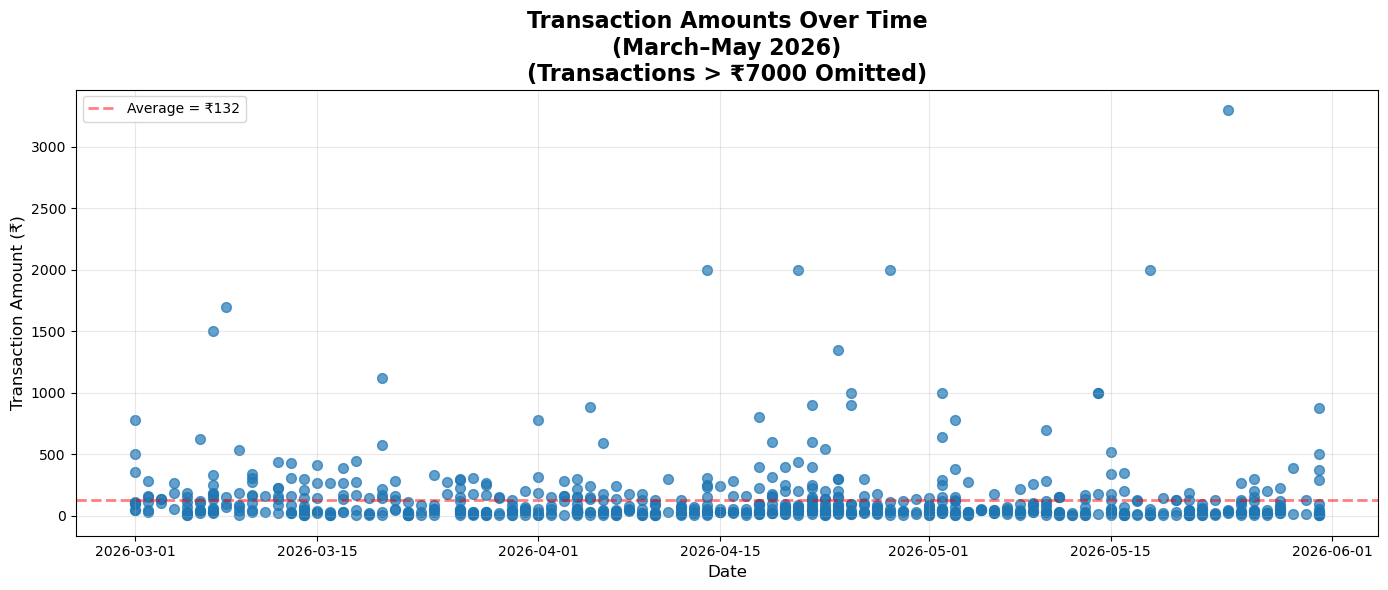

In [57]:
# =============================================================================
# STEP 6.10 : TRANSACTION AMOUNTS OVER TIME (OMIT > ₹7000)
# =============================================================================

# -------------------------------------------------------------------------
# Filter Transactions
# -------------------------------------------------------------------------

scatter_df = expense_df[expense_df["Amount"] <= 7000].copy()

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

plt.figure(figsize=(14,6))

plt.scatter(
    scatter_df["Date"],
    scatter_df["Amount"],
    s=50,
    alpha=0.7
)

# Average line
average_amount = scatter_df["Amount"].mean()

plt.axhline(
    average_amount,
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.5,
    label=f"Average = ₹{average_amount:,.0f}"
)

plt.title(
    "Transaction Amounts Over Time\n(March–May 2026)\n(Transactions > ₹7000 Omitted)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Transaction Amount (₹)", fontsize=12)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

# -------------------------------------------------------------------------
# Save Figure
# -------------------------------------------------------------------------

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "10_Transaction_Amounts_Over_Time_March_to_May_2026.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

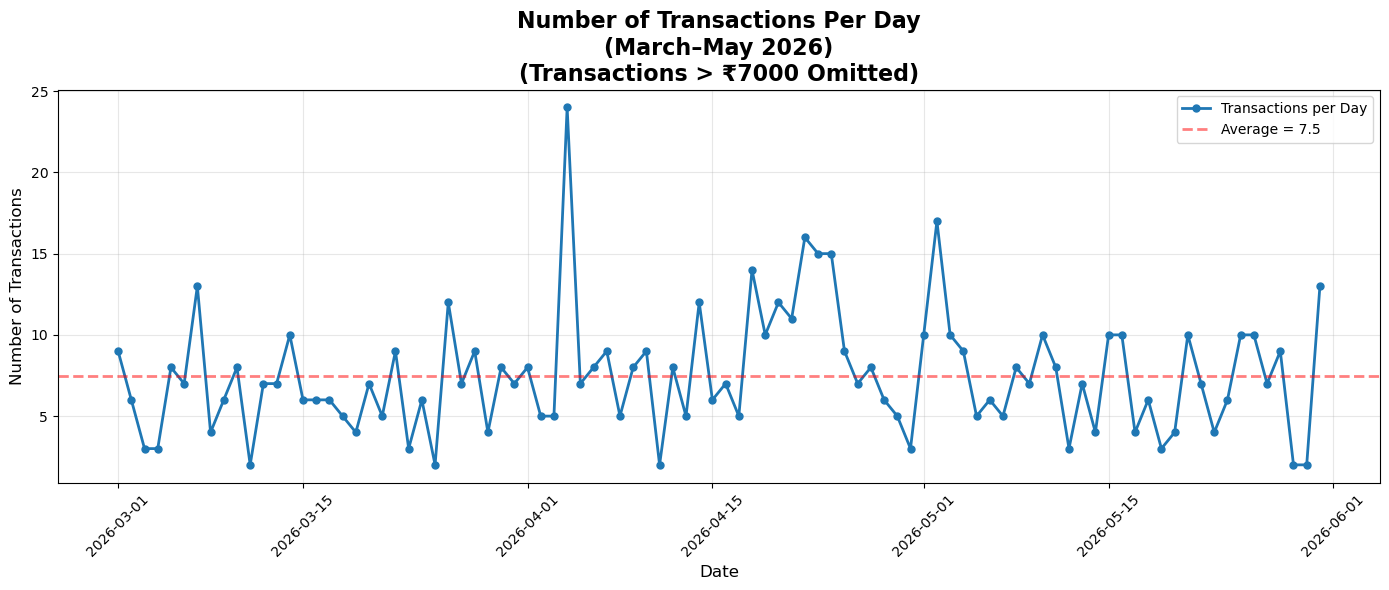

In [58]:
# =============================================================================
# STEP 6.10 : NUMBER OF TRANSACTIONS PER DAY
# =============================================================================

# -------------------------------------------------------------------------
# Filter Transactions (omit > ₹7000)
# -------------------------------------------------------------------------

transaction_count = (
    expense_df[expense_df["Amount"] <= 7000]
    .groupby("Date")
    .size()
    .reset_index(name="Transactions")
)

# Average transactions per day
average_transactions = transaction_count["Transactions"].mean()

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    transaction_count["Date"],
    transaction_count["Transactions"],
    marker="o",
    linewidth=2,
    markersize=5,
    label="Transactions per Day"
)

plt.axhline(
    average_transactions,
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.5,
    label=f"Average = {average_transactions:.1f}"
)

plt.title(
    "Number of Transactions Per Day\n(March–May 2026)\n(Transactions > ₹7000 Omitted)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)

plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

# -------------------------------------------------------------------------
# Save Figure
# -------------------------------------------------------------------------

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "10_Number_of_Transactions_Per_Day_March_to_May_2026.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

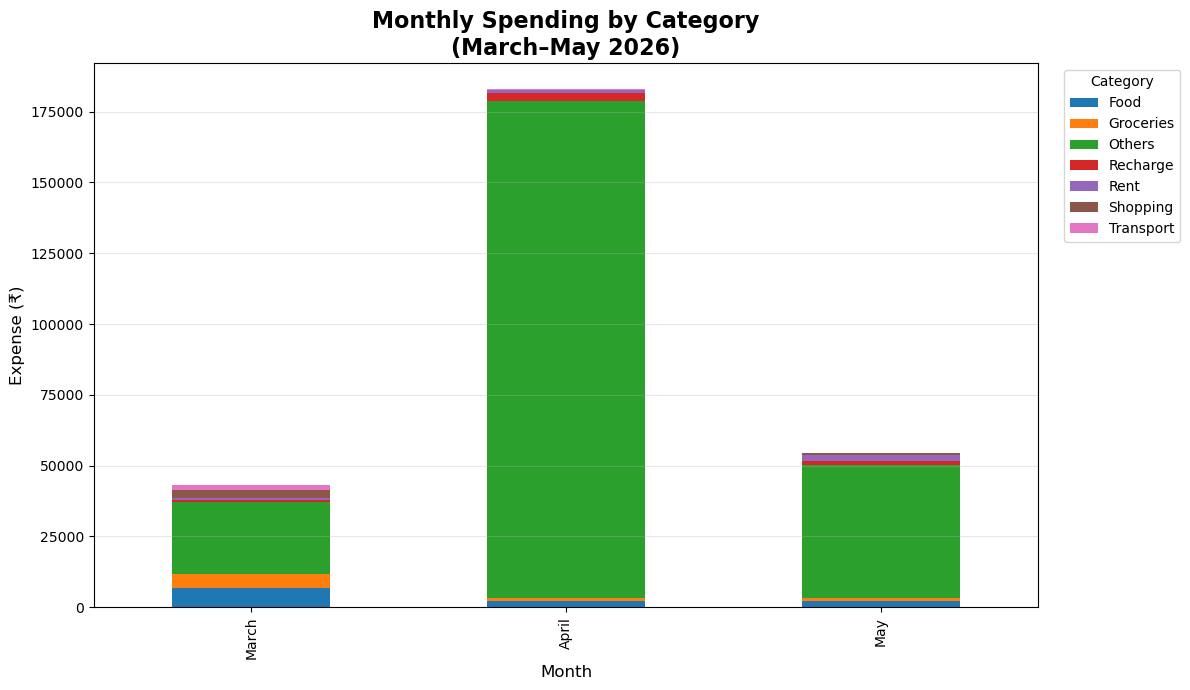

In [59]:
# =============================================================================
# STEP 6.11 : MONTHLY SPENDING BY CATEGORY
# =============================================================================

# -------------------------------------------------------------------------
# Prepare Data
# -------------------------------------------------------------------------

category_month = (
    expense_df
    .groupby(["Month", "Category"])["Amount"]
    .sum()
    .unstack(fill_value=0)
)

# Calendar order
month_order = ["March", "April", "May"]

category_month = category_month.reindex(month_order)

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

plt.figure(figsize=(12,7))

category_month.plot(
    kind="bar",
    stacked=True,
    ax=plt.gca()
)

plt.title(
    "Monthly Spending by Category\n(March–May 2026)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Expense (₹)", fontsize=12)

plt.grid(axis="y", alpha=0.3)

plt.legend(
    title="Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# -------------------------------------------------------------------------
# Save Figure
# -------------------------------------------------------------------------

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "11_Monthly_Spending_by_Category_March_to_May_2026.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

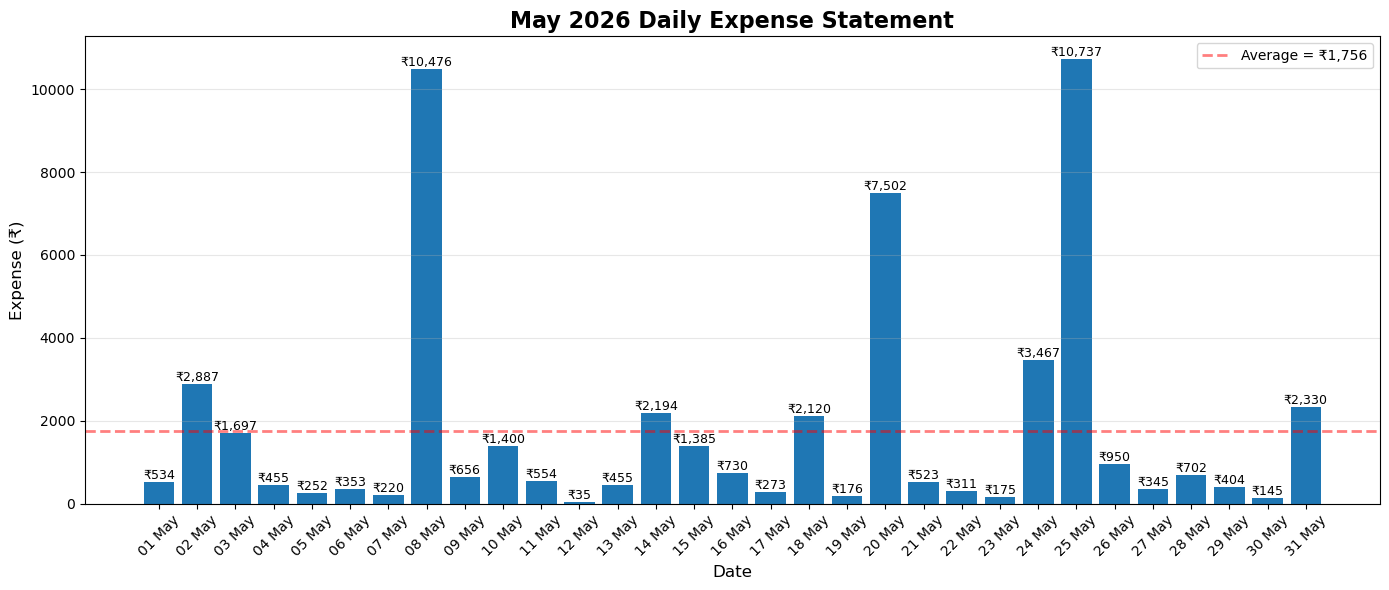

In [60]:
# =============================================================================
# MAY 2026 DAILY EXPENSE STATEMENT
# =============================================================================

# -------------------------------------------------------------------------
# Filter May Expenses
# -------------------------------------------------------------------------

may_expense = expense_df[
    (expense_df["Date"].dt.month == 5) &
    (expense_df["Date"].dt.year == 2026)
]

# -------------------------------------------------------------------------
# Daily Summary
# -------------------------------------------------------------------------

may_daily = (
    may_expense
    .groupby("Date")["Amount"]
    .sum()
    .reset_index()
)

average_daily = may_daily["Amount"].mean()

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

plt.figure(figsize=(14,6))

plt.bar(
    may_daily["Date"].dt.strftime("%d %b"),
    may_daily["Amount"]
)

# Value labels
for i, value in enumerate(may_daily["Amount"]):

    plt.text(
        i,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Average line
plt.axhline(
    average_daily,
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.5,
    label=f"Average = ₹{average_daily:,.0f}"
)

plt.title(
    "May 2026 Daily Expense Statement",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Date", fontsize=12)
plt.ylabel("Expense (₹)", fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

# -------------------------------------------------------------------------
# Save Figure
# -------------------------------------------------------------------------

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "12_May_2026_Daily_Expense_Statement.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

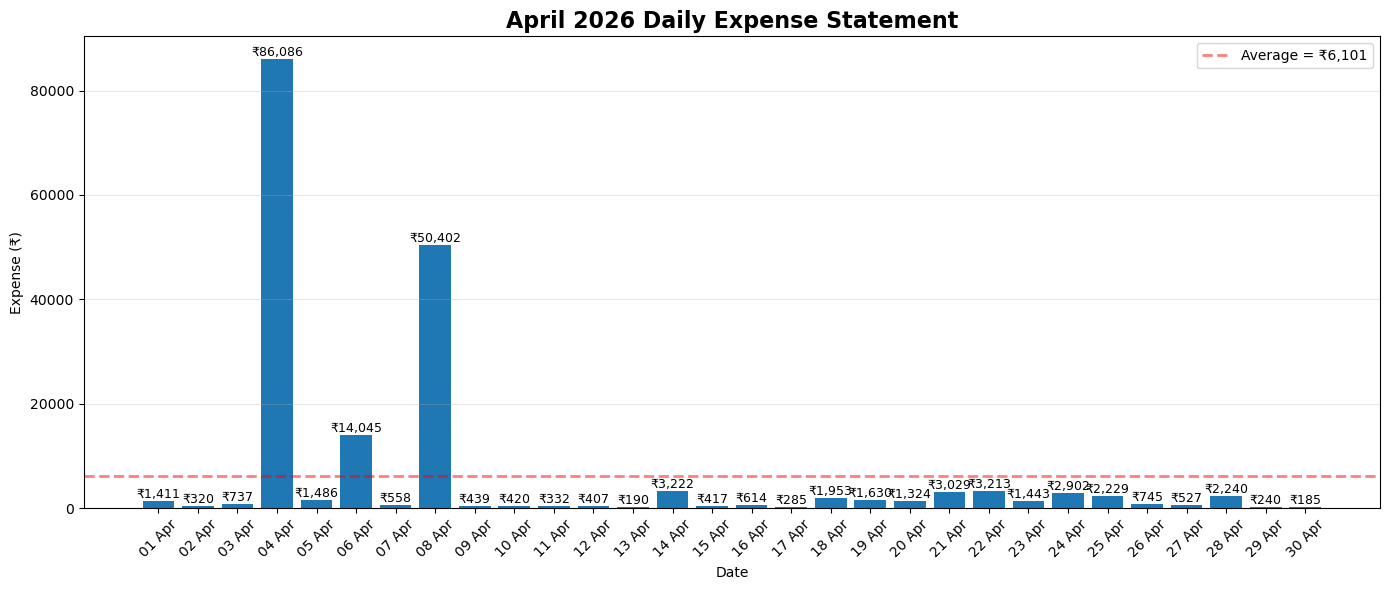

In [61]:
# =============================================================================
# APRIL 2026 DAILY EXPENSE STATEMENT
# =============================================================================

# -------------------------------------------------------------------------
# Filter April Expenses
# -------------------------------------------------------------------------

april_expense = expense_df[
    (expense_df["Date"].dt.month == 4) &
    (expense_df["Date"].dt.year == 2026)
]

# -------------------------------------------------------------------------
# Daily Summary
# -------------------------------------------------------------------------

april_daily = (
    april_expense
    .groupby("Date")["Amount"]
    .sum()
    .reset_index()
)

average_daily = april_daily["Amount"].mean()

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

plt.figure(figsize=(14,6))

bars = plt.bar(
    april_daily["Date"].dt.strftime("%d %b"),
    april_daily["Amount"]
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.axhline(
    average_daily,
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.5,
    label=f"Average = ₹{average_daily:,.0f}"
)

plt.title(
    "April 2026 Daily Expense Statement",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Date")
plt.ylabel("Expense (₹)")

plt.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "12_April_2026_Daily_Expense_Statement.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

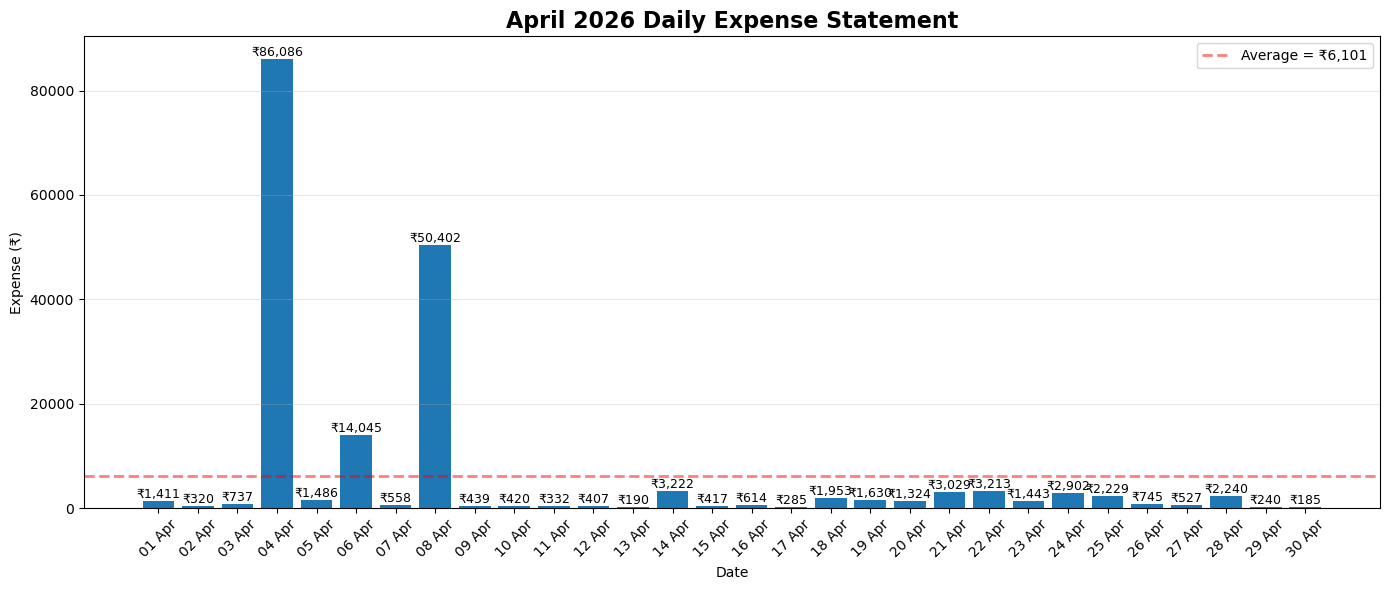

In [62]:
# =============================================================================
# APRIL 2026 DAILY EXPENSE STATEMENT
# =============================================================================

# -------------------------------------------------------------------------
# Filter April Expenses
# -------------------------------------------------------------------------

april_expense = expense_df[
    (expense_df["Date"].dt.month == 4) &
    (expense_df["Date"].dt.year == 2026)
]

# -------------------------------------------------------------------------
# Daily Summary
# -------------------------------------------------------------------------

april_daily = (
    april_expense
    .groupby("Date")["Amount"]
    .sum()
    .reset_index()
)

average_daily = april_daily["Amount"].mean()

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

plt.figure(figsize=(14,6))

bars = plt.bar(
    april_daily["Date"].dt.strftime("%d %b"),
    april_daily["Amount"]
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.axhline(
    average_daily,
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.5,
    label=f"Average = ₹{average_daily:,.0f}"
)

plt.title(
    "April 2026 Daily Expense Statement",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Date")
plt.ylabel("Expense (₹)")

plt.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "12_April_2026_Daily_Expense_Statement.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

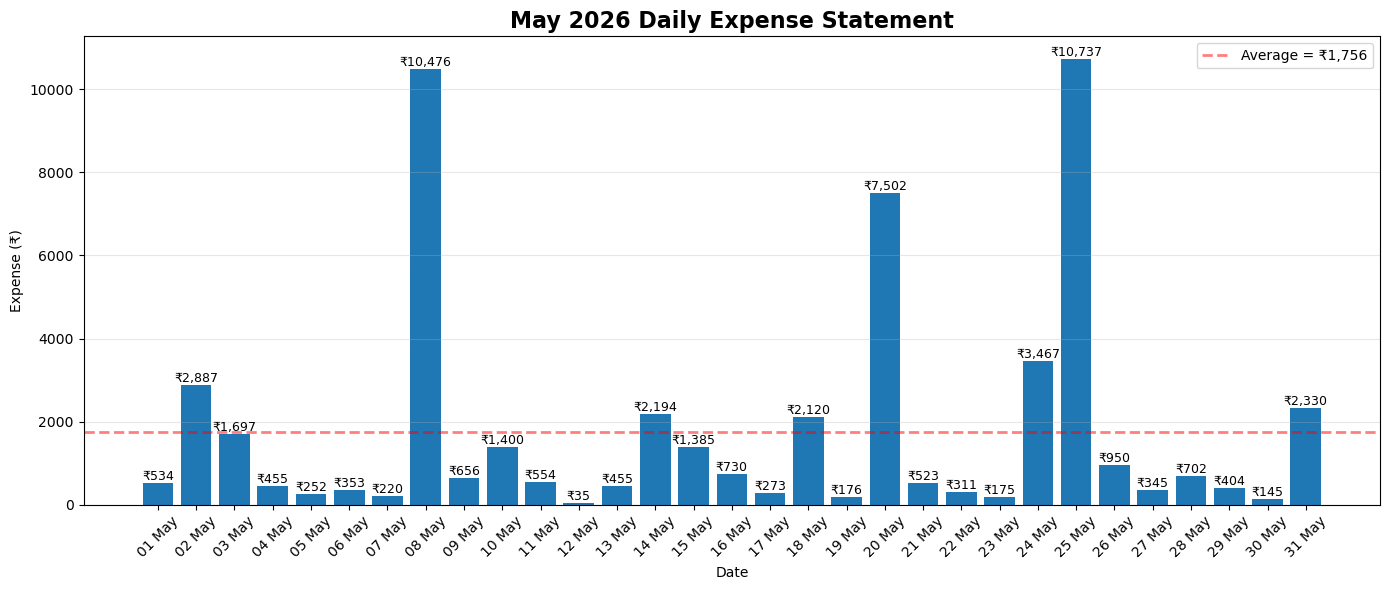

In [63]:
# =============================================================================
# MAY 2026 DAILY EXPENSE STATEMENT
# =============================================================================

# -------------------------------------------------------------------------
# Filter May Expenses
# -------------------------------------------------------------------------

may_expense = expense_df[
    (expense_df["Date"].dt.month == 5) &
    (expense_df["Date"].dt.year == 2026)
]

# -------------------------------------------------------------------------
# Daily Summary
# -------------------------------------------------------------------------

may_daily = (
    may_expense
    .groupby("Date")["Amount"]
    .sum()
    .reset_index()
)

average_daily = may_daily["Amount"].mean()

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

plt.figure(figsize=(14,6))

bars = plt.bar(
    may_daily["Date"].dt.strftime("%d %b"),
    may_daily["Amount"]
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.axhline(
    average_daily,
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.5,
    label=f"Average = ₹{average_daily:,.0f}"
)

plt.title(
    "May 2026 Daily Expense Statement",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Date")
plt.ylabel("Expense (₹)")

plt.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "13_May_2026_Daily_Expense_Statement.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

In [84]:
# =============================================================================
# FINAL ROOM RENT RULE
# =============================================================================

# Remove any existing Room Rent labels
df.loc[df["Category"] == "Room Rent", "Category"] = "Others"

# Mark ONLY transactions satisfying ALL conditions
rent_mask = (
    (df["Type"] == "Expense") &
    (df["Amount"].between(10000, 11000)) &
    (df["Date"].dt.day.between(1, 7))
)

df.loc[rent_mask, "Category"] = "Room Rent"

# Refresh expense dataframe
expense_df = df[df["Type"] == "Expense"].copy()

print(expense_df[expense_df["Category"] == "Room Rent"]
      [["Date", "Merchant", "Amount", "Category"]])

Empty DataFrame
Columns: [Date, Merchant, Amount, Category]
Index: []


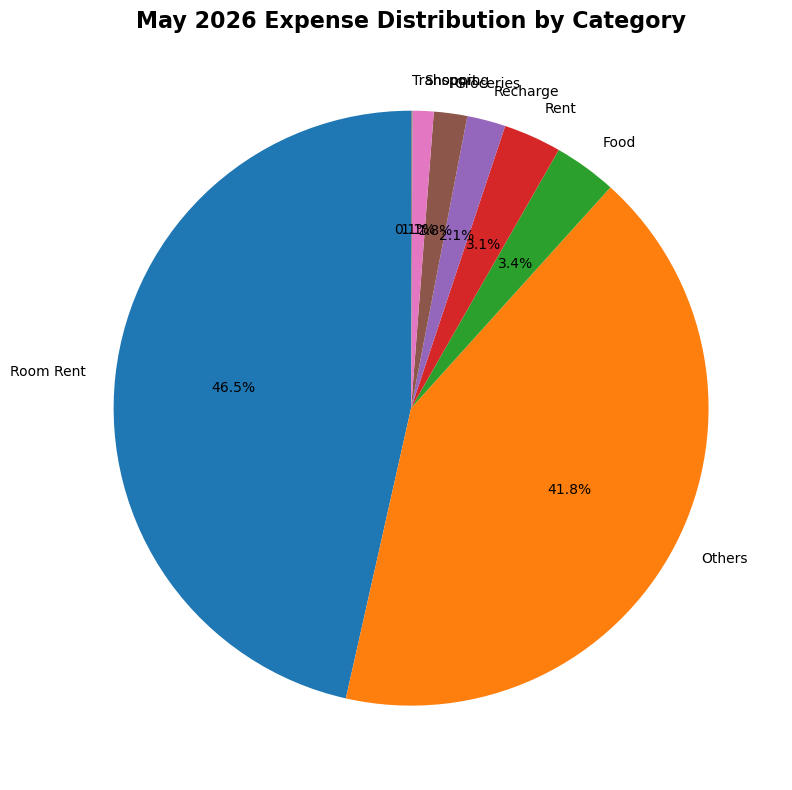

In [82]:
# =============================================================================
# MAY CATEGORY PIE CHART
# =============================================================================

may_expense = expense_df[
    (expense_df["Date"].dt.month == 5) &
    (expense_df["Date"].dt.year == 2026)
]

may_category = (
    may_expense
    .groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))

plt.pie(
    may_category.values,
    labels=may_category.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("May 2026 Expense Distribution by Category",
          fontsize=16,
          weight="bold")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "14_May_Expense_Category_Pie_Chart.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

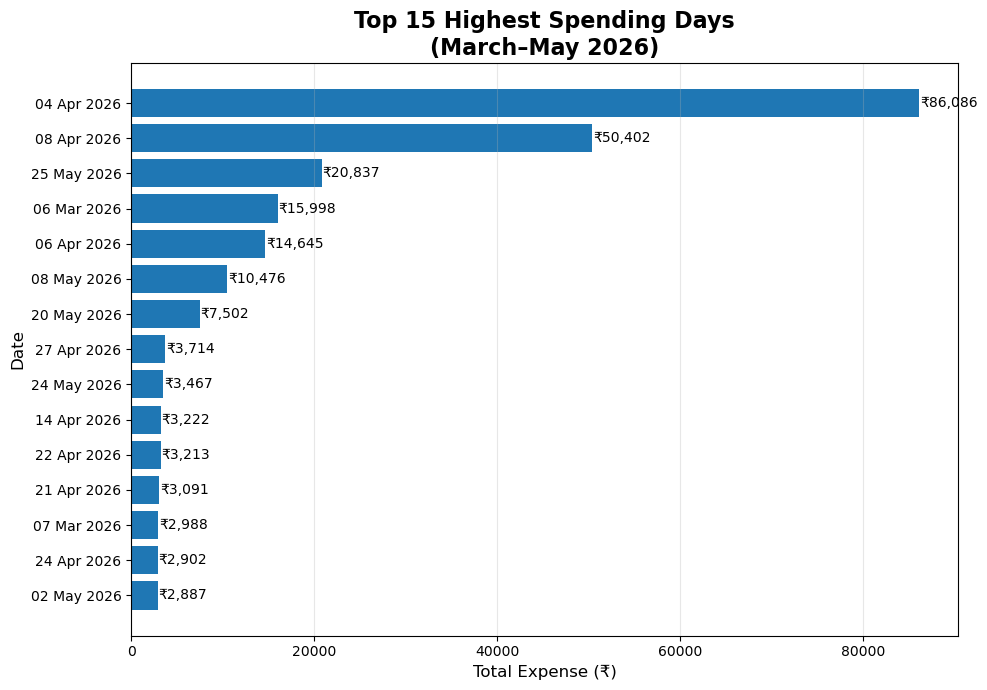

In [85]:
# =============================================================================
# STEP 6.12 : TOP 15 MOST EXPENSIVE DAYS
# =============================================================================

# -------------------------------------------------------------------------
# Daily Expense Summary
# -------------------------------------------------------------------------

top_days = (
    expense_df
    .groupby("Date")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

plt.figure(figsize=(10,7))

bars = plt.barh(
    top_days.index.strftime("%d %b %Y"),
    top_days.values
)

# Value Labels
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 100,
        bar.get_y() + bar.get_height()/2,
        f"₹{width:,.0f}",
        va="center",
        fontsize=10
    )

plt.xlabel("Total Expense (₹)", fontsize=12)
plt.ylabel("Date", fontsize=12)

plt.title(
    "Top 15 Highest Spending Days\n(March–May 2026)",
    fontsize=16,
    weight="bold"
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

# -------------------------------------------------------------------------
# Save Figure
# -------------------------------------------------------------------------

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "15_Top_15_Highest_Spending_Days_March_to_May_2026.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()